# How to Train YOLOv11n Object Detection on a Custom Dataset


## Before you start

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.


In [1]:
import cv2
import matplotlib.pyplot    

In [2]:
import os

HOME = os.getcwd()
print(HOME)

/home/robiotec/Documents/ENTRENAMIENTOS/Entrenamiento


## 🗹 Check Ultralytics , Torch and CUDA


In [3]:
from IPython import display

display.clear_output()

import ultralytics

ultralytics.checks()

import torch

print(torch.cuda.is_available())
print(torch.__version__)
print(torch.cuda.get_device_name(0))

Ultralytics 8.4.13 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24073MiB)
Setup complete ✅ (20 CPUs, 62.3 GB RAM, 60.9/457.3 GB disk)
True
2.10.0+cu128
NVIDIA GeForce RTX 4090


### 🐍 Python SDK

The simplest way of simply using YOLOv11n directly in a Python environment.


### Model Training with Complex Parameters


In [ ]:
!yolo task=detect mode=train model=best_11n.pt data=/home/robiotec/Documents/smart-sorter-system/model/data/SMART-20-01-2026/data.yaml \
    epochs=750 \
    batch=48 \
    plots=True \
    device=0 \
    conf=0.45 \
    iou=0.5 \
    patience=100 \
    warmup_epochs=15 \
    save_period=25 \
    lr0=0.0015 \
    lrf=0.00015 \
    weight_decay=0.0003 \
    label_smoothing=0.3 \
    mosaic=1.0 \
    mixup=0.4 \
    hsv_h=0.03 \
    hsv_s=0.9 \
    hsv_v=0.6 \
    degrees=70 \
    translate=0.3 \
    scale=0.8 \
    shear=15 \
    perspective=0.002 \
    flipud=0.5 \
    fliplr=0.5 \
    cos_lr=True \
    close_mosaic=20 \
    multi_scale=True \
    workers=12 \
    amp=True \
    cache=ram \
    pretrained=True \
    freeze=10

YOLO 11 ENTRENADO CON ONE CLASS


In [ ]:
!yolo task=detect mode=train \
model={HOME}/model/yolo26n.pt\
data= data.yaml \
project={HOME}/result \
name=one_class_caja \
epochs=150 batch=64 plots=True device=0 conf=0.6 patience=30 warmup_epochs=3 save_period=10 seed=42 lr0=0.01 lrf=0.0001 weight_decay=0.0005 

New https://pypi.org/project/ultralytics/8.4.14 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.13 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24073MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=0.6, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.0001, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/home/robiotec/Documents/ENTRENAMIENTOS/Entrenamiento/model/yolo26n.pt, momentum=

In [ ]:
!yolo task=detect mode=val \
  model={HOME}/result/two_class/weights/best.pt \
  data=data.yaml \
  split=test \
  device=0 \
  plots=True \
  project=${HOME}/result/two_class/metrics \
  name=val_test \
  conf=0.6 \
  exist_ok=True 



Ultralytics 8.4.13 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24073MiB)
YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1466.7±1910.7 MB/s, size: 26.8 KB)
val: Scanning /home/robiotec/Documents/ENTRENAMIENTOS/Entrenamiento/data/DS_TWO_CLASS/test/labels... 4945 images, 991 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4945/4945 6.7Kit/s 0.7s0.0s
val: New cache created: /home/robiotec/Documents/ENTRENAMIENTOS/Entrenamiento/data/DS_TWO_CLASS/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 310/310 66.3it/s 4.7s0.1s
                   all       4945       6151      0.934      0.918      0.955      0.934
                  caja       2453       3834      0.938        0.9      0.946      0.923
                  veta       1501       2317      0.929      0.937      0.963      0.944
Speed: 0.0ms preprocess, 0.2ms 

/home/robiotec/Documents/ENTRENAMIENTOS/Entrenamiento


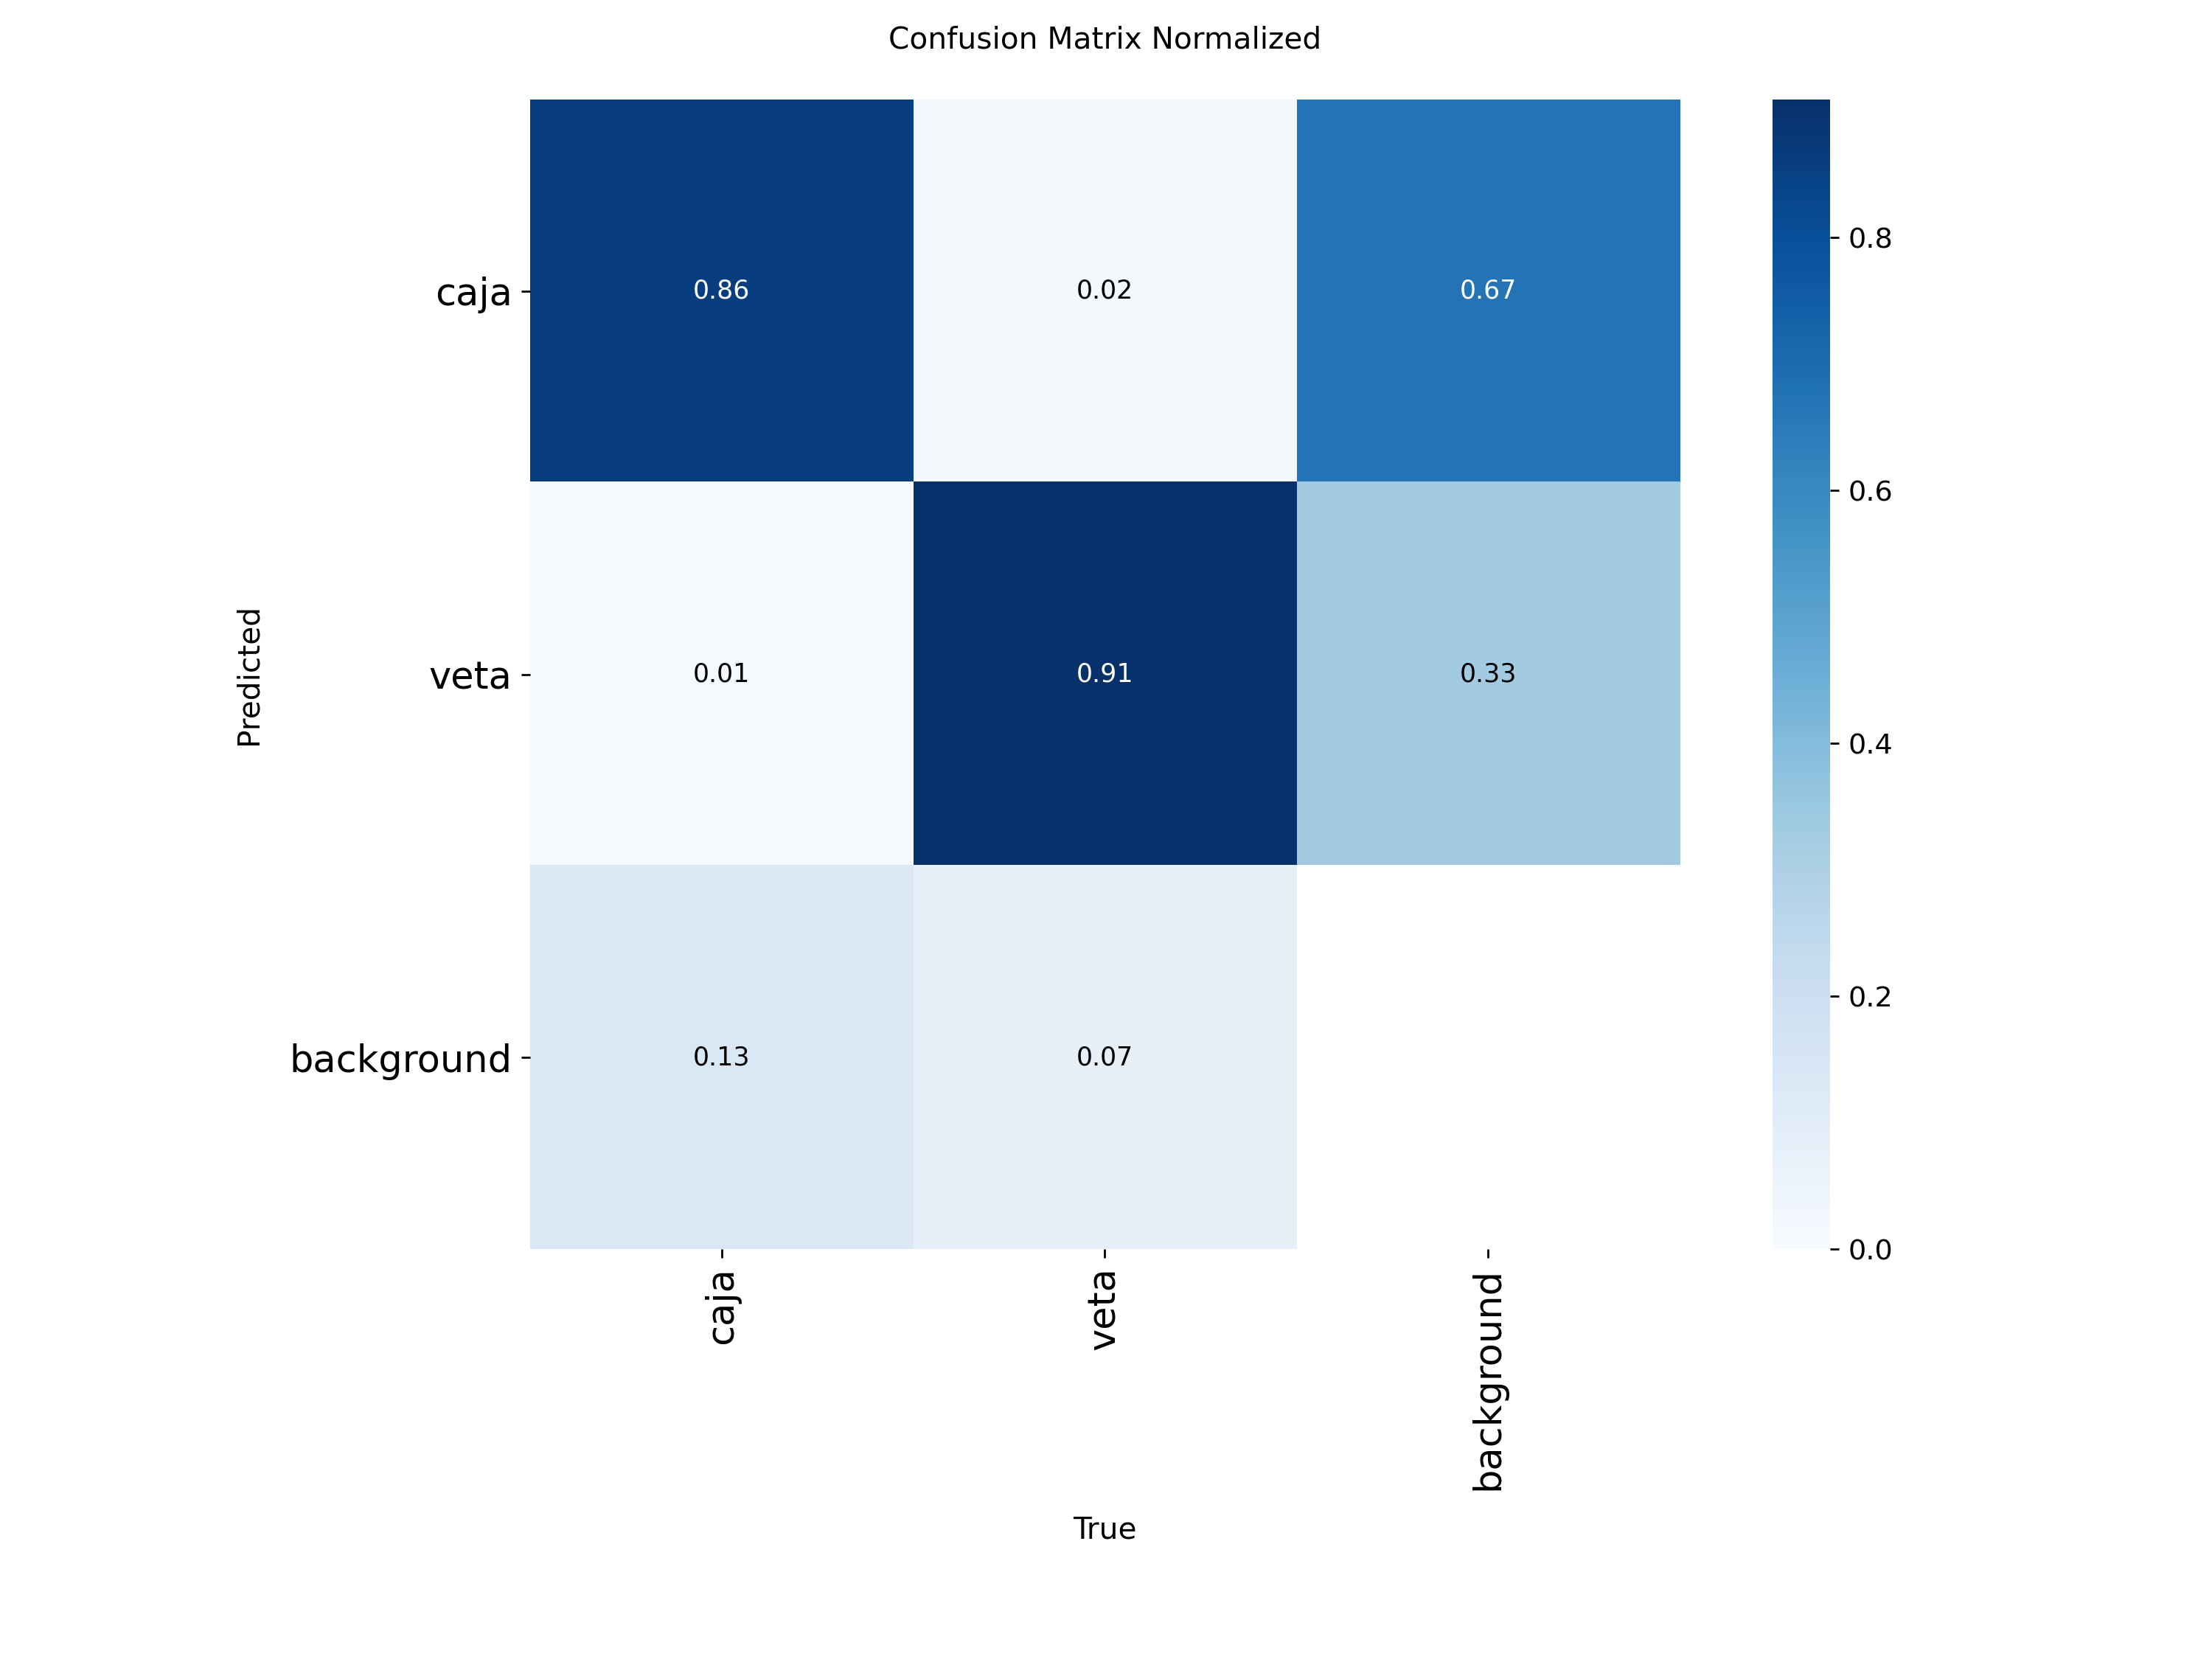

In [17]:
from IPython.display import display, Image

%cd {HOME}
Image(filename=f"{HOME}/result/two_class/confusion_matrix_normalized.png", width=900)